**HEART DISEASE PREDICTION USING MACHINE LEARNING**


---



**1. OBJECTIVE:**
The main objective of this project is to analyze patient health data and predict the likelihood of heart disease using machine learning techniques. The project also aims to identify important health factors affecting heart disease.

In [ ]:

import pandas as pd
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [ ]:
from google.colab import files
uploaded=files.upload()

Saving heart_disease_dataset.csv to heart_disease_dataset.csv


**Step 1: Data Collection**

In [ ]:
df=pd.read_csv("heart_disease_dataset.csv")
df.head(10)

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0
5,77,Male,309,110,73,Never,NaN,0,No,Yes,Yes,4,122,Yes,Asymptomatic,1
6,64,Female,211,105,86,Former,Heavy,8,Yes,Yes,Yes,2,120,No,Typical Angina,1
7,60,Female,208,148,83,Never,Moderate,4,No,Yes,Yes,2,113,Yes,Asymptomatic,1
8,37,Female,317,137,66,Current,Heavy,3,No,Yes,Yes,5,114,No,Non-anginal Pain,0
9,63,Male,204,141,68,Former,Heavy,8,No,Yes,No,3,107,No,Asymptomatic,1


**Step 2: Data Preprocessing**

In [ ]:
print("duplicate values count before cleaning",df.duplicated().sum())
#remove duplicates
df.drop_duplicates(inplace=True)
print("duplicate values count after cleaning",df.duplicated().sum())
#remove null values
print("null values count before cleaning \n",df.isnull().sum())
df.dropna(inplace=True)
print("\n null values count after cleaning \n",df.isnull().sum())

duplicate values count before cleaning 0
duplicate values count after cleaning 0
null values count before cleaning 
 Age                          0
Gender                       0
Cholesterol                  0
Blood_Pressure               0
Heart_Rate                   0
Smoking                      0
Alcohol_Intake             340
Exercise_Hours               0
Family_History               0
Diabetes                     0
Obesity                      0
Stress_Level                 0
Blood_Sugar                  0
Exercise_Induced_Angina      0
Chest_Pain_Type              0
Heart_Disease                0
dtype: int64

 null values count after cleaning 
 Age                        0
Gender                     0
Cholesterol                0
Blood_Pressure             0
Heart_Rate                 0
Smoking                    0
Alcohol_Intake             0
Exercise_Hours             0
Family_History             0
Diabetes                   0
Obesity                    0
Stress_Level      

In [ ]:
#UPDATING THE COLUMN NAMES
df.columns = df.columns.str.replace(' ', '_')
df.head()

,Age,Gender,Cholesterol,Blood_Pressure,Heart_Rate,Smoking,Alcohol_Intake,Exercise_Hours,Family_History,Diabetes,Obesity,Stress_Level,Blood_Sugar,Exercise_Induced_Angina,Chest_Pain_Type,Heart_Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


In [ ]:
# REPLACING THE VALUE 0 WITH NO AND 1 WITH YES IN HEART_DISEASE COLM
df["Heart_Disease"]=df["Heart_Disease"].replace({0:"NO",1:"YES"})
df.head()

,Age,Gender,Cholesterol,Blood_Pressure,Heart_Rate,Smoking,Alcohol_Intake,Exercise_Hours,Family_History,Diabetes,Obesity,Stress_Level,Blood_Sugar,Exercise_Induced_Angina,Chest_Pain_Type,Heart_Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,YES
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,NO
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,YES
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,NO
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,NO


**Step 3: Data Summarization**

In [ ]:
A=df.groupby("Gender")["Heart_Disease"].value_counts().reset_index();print(A)
print("INSIGHT: FEMALES SUFFER LESS HEART DISEASE WHEN COMPARED TO MEN")

   Gender Heart_Disease  count
0  Female            NO    313
1  Female           YES    190
2    Male            NO    295
3    Male           YES    202
INSIGHT: FEMALES SUFFER LESS HEART DISEASE WHEN COMPARED TO MEN


In [ ]:
cp = df.groupby("Chest_Pain_Type")["Heart_Disease"].value_counts().reset_index(name="count")
print(cp)
print("\nINSIGHT:\nPatients with non-anginal pain showed the lowest number of heart disease cases, while asymptomatic and atypical angina patients had comparatively higher heart disease occurrences.")

    Chest_Pain_Type Heart_Disease  count
0      Asymptomatic            NO    146
1      Asymptomatic           YES    102
2   Atypical Angina            NO    146
3   Atypical Angina           YES    100
4  Non-anginal Pain            NO    166
5  Non-anginal Pain           YES     90
6    Typical Angina            NO    150
7    Typical Angina           YES    100

INSIGHT:
Patients with non-anginal pain showed the lowest number of heart disease cases, while asymptomatic and atypical angina patients had comparatively higher heart disease occurrences.


**Step 4:Exploratory Data Analysis (EDA)**

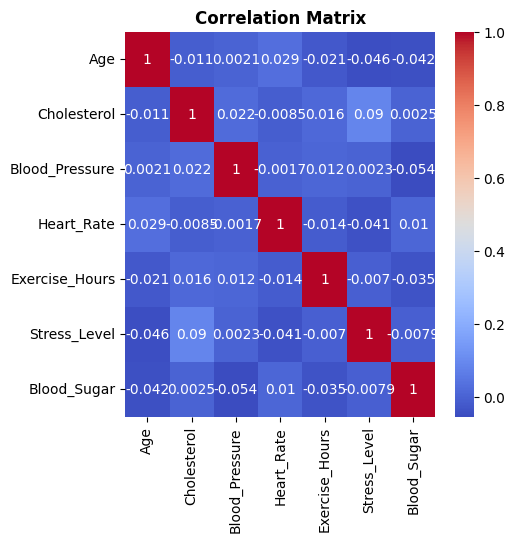

In [ ]:

plt.figure(figsize=(5,5))
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix",fontweight='bold')
df.select_dtypes(exclude="object").columns
plt.show()

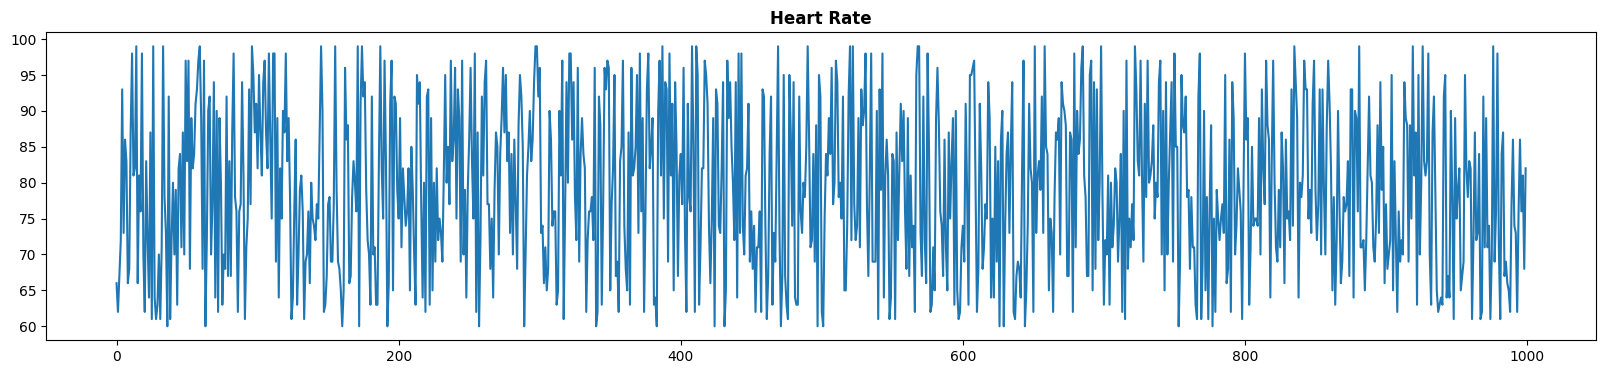

In [ ]:
#line graph of heart rate
plt.figure(figsize=(20,4))
plt.plot(df["Heart_Rate"])
plt.title("Heart Rate",fontweight='bold')
plt.show()

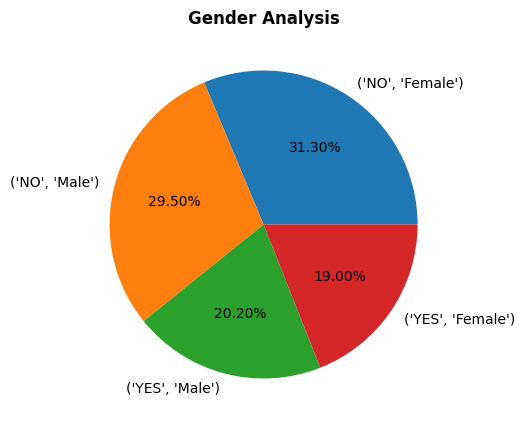


INSIGHT:
Combined, individuals without heart disease would make up the majority of the dataset at 60.80% (31.30% Female + 29.50% Male).


In [ ]:
# GENDER ANALYSIS
a = df.groupby("Heart_Disease")['Gender'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(a.values, labels=a.index, autopct='%1.2f%%')
plt.title("Gender Analysis", fontweight='bold')
plt.show()

print("\nINSIGHT:\nCombined, individuals without heart disease would make up the majority of the dataset at 60.80% (31.30% Female + 29.50% Male).")

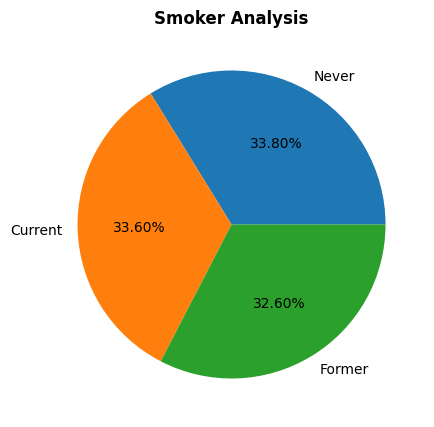

INSIGHT:
There is no single dominant group.


In [ ]:
#NUMBER OF SMOKERS IN EACH STAGE
a = df['Smoking'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(a.values,labels=a.index,autopct='%1.2f%%')
plt.title("Smoker Analysis", fontweight='bold')
plt.show()
print("INSIGHT:\nThere is no single dominant group.")

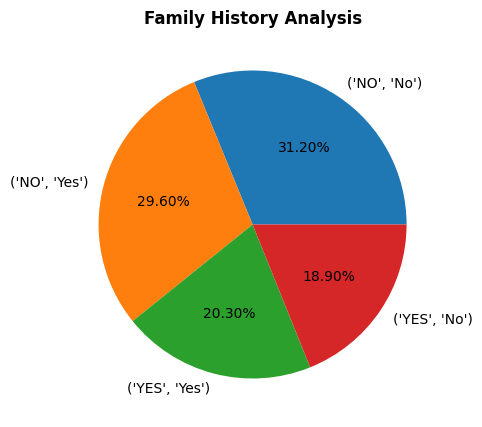


INSIGHT:
The chart shows that the largest group of patients had no family history (31.20%) and no heart disease (NO, NO), while a significant percentage of 20.3% with family history (YES, YES) were associated with heart disease.


In [ ]:
#Family History Analysis
plt.figure(figsize=(5,5))
a=df.groupby("Heart_Disease")["Family_History"].value_counts()
plt.pie(a.values,labels=a.index,autopct='%1.2f%%')
plt.title("Family History Analysis",fontweight='bold')
plt.show()
print("\nINSIGHT:\nThe chart shows that the largest group of patients had no family history (31.20%) and no heart disease (NO, NO), while a significant percentage of 20.3% with family history (YES, YES) were associated with heart disease.")

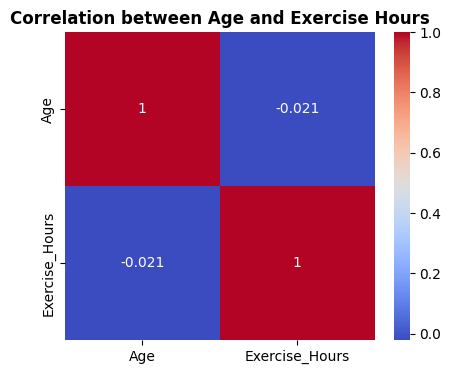


INSIGHT:
An older person is just as likely to exercise a lot (or a little) as a younger person.


In [ ]:
#Correlation between Age and Exercise Hours
plt.figure(figsize=(5,4))
sns.heatmap(df[["Age","Exercise_Hours"]].corr(),annot=True,cmap="coolwarm")
plt.title("Correlation between Age and Exercise Hours",fontweight="bold")
plt.show()
print("\nINSIGHT:\nAn older person is just as likely to exercise a lot (or a little) as a younger person.")

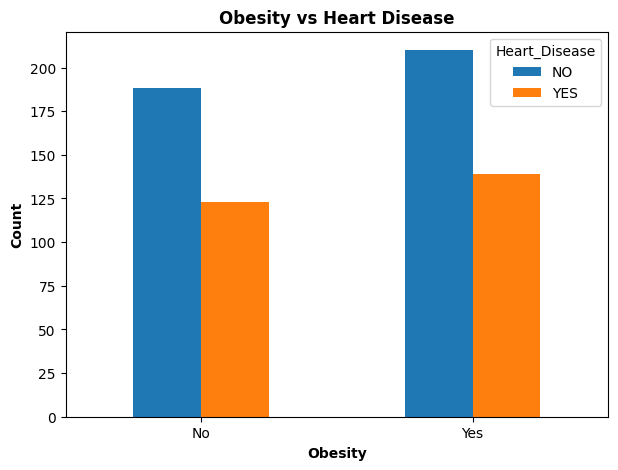


INSIGHT:
Patients with obesity showed a higher occurrence of heart disease compared to non-obese patients.


In [ ]:
# Obesity vs Heart Disease

ob = df.groupby("Obesity")["Heart_Disease"].value_counts().unstack()
ob.plot(kind='bar', figsize=(7,5))
plt.title("Obesity vs Heart Disease", fontweight='bold')
plt.xlabel("Obesity", fontweight='bold')
plt.ylabel("Count", fontweight='bold')
plt.xticks(rotation=0)
plt.show()
print("\nINSIGHT:\nPatients with obesity showed a higher occurrence of heart disease compared to non-obese patients.")

In [ ]:
# STEP : QUERY USING AGE CATEGORIES

kids = df.query("Heart_Disease == 'YES' and Gender == 'Male' and Age < 13").shape[0]
teens = df.query("Heart_Disease == 'YES' and Gender == 'Male' and Age >= 13 and Age <= 19").shape[0]
young_adults = df.query("Heart_Disease == 'YES' and Gender == 'Male' and Age >= 20 and Age <= 35").shape[0]
adults = df.query("Heart_Disease == 'YES' and Gender == 'Male' and Age >= 36 and Age <= 52").shape[0]
older = df.query("Heart_Disease == 'YES' and Gender == 'Male' and Age > 52").shape[0]
print("KIDS WITH HEART DISEASE:", kids)
print("TEENS WITH HEART DISEASE:", teens)
print("YOUNG ADULTS WITH HEART DISEASE:", young_adults)
print("ADULTS WITH HEART DISEASE:", adults)
print("OLDER PEOPLE WITH HEART DISEASE:", older)

print("\nINSIGHT:\n1.Older males (above 52 years) have the highest number of heart disease cases.\n2.increasing age may be an important factor associated with heart disease risk.")

KIDS WITH HEART DISEASE: 0
TEENS WITH HEART DISEASE: 0
YOUNG ADULTS WITH HEART DISEASE: 0
ADULTS WITH HEART DISEASE: 17
OLDER PEOPLE WITH HEART DISEASE: 185

INSIGHT:
1.Older males (above 52 years) have the highest number of heart disease cases.
2.increasing age may be an important factor associated with heart disease risk.


In [ ]:
# Older male patients with high cholesterol
m1 = df.query("Age > 50 and Cholesterol > 240 and Gender =='Male' ").shape[0]
# Younger female patients with normal cholesterol
f1 = df.query("Age < 40 and Cholesterol < 200 and Gender =='Female'").shape[0]
print("OLDER MALES WITH HIGH CHOLESTEROL :", m1)
print("YOUNGER FEMALES WITH NORMAL CHOLESTEROL :", f1)
print("\nINSIGHT:\n1.Older male patients showed higher cholesterol levels more frequently, while younger females mostly had normal cholesterol levels.\n2.This indicates that age and gender may influence cholesterol-related heart risk factors.")

OLDER MALES WITH HIGH CHOLESTEROL : 151
YOUNGER FEMALES WITH NORMAL CHOLESTEROL : 24

INSIGHT:
1.Older male patients showed higher cholesterol levels more frequently, while younger females mostly had normal cholesterol levels.
2.This indicates that age and gender may influence cholesterol-related heart risk factors.


**Step 5:Model Building**

In [ ]:
# Converting category colm to numbers
cat_cols=df.select_dtypes(include="object").columns
le=LabelEncoder()
for i in cat_cols:
  df[i]=le.fit_transform(df[i])
df.head()

,Age,Gender,Cholesterol,Blood_Pressure,Heart_Rate,Smoking,Alcohol_Intake,Exercise_Hours,Family_History,Diabetes,Obesity,Stress_Level,Blood_Sugar,Exercise_Induced_Angina,Chest_Pain_Type,Heart_Disease
0,75,0,228,119,66,0,0,1,0,0,1,8,119,1,1,1
1,48,1,204,165,62,0,2,5,0,0,0,9,70,1,3,0
2,53,1,234,91,67,2,0,3,1,0,1,5,196,1,1,1
3,69,0,192,90,72,0,2,4,0,1,0,7,107,1,2,0
4,62,0,172,163,93,2,2,6,0,1,0,2,183,1,0,0


In [ ]:
#SPLITING THE DATA
X=df.drop("Heart_Disease",axis=1)
y=df["Heart_Disease"]

In [ ]:
X

,Age,Gender,Cholesterol,Blood_Pressure,Heart_Rate,Smoking,Alcohol_Intake,Exercise_Hours,Family_History,Diabetes,Obesity,Stress_Level,Blood_Sugar,Exercise_Induced_Angina,Chest_Pain_Type
0,75,0,228,119,66,0,0,1,0,0,1,8,119,1,1
1,48,1,204,165,62,0,2,5,0,0,0,9,70,1,3
2,53,1,234,91,67,2,0,3,1,0,1,5,196,1,1
3,69,0,192,90,72,0,2,4,0,1,0,7,107,1,2
4,62,0,172,163,93,2,2,6,0,1,0,2,183,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,56,0,269,111,86,2,0,5,0,1,1,10,120,0,2
996,78,0,334,145,76,2,2,6,0,0,0,10,196,1,3
997,79,1,151,179,81,2,1,4,1,0,1,8,189,1,0
998,60,0,326,151,68,1,2,8,1,1,0,5,174,1,1


In [ ]:
y

,Heart_Disease
0,1
1,0
2,1
3,0
4,0
...,...
995,1
996,1
997,0
998,1


In [ ]:
#TRAIN TEST SPLIT
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


In [ ]:
#SCALING/CONVERT NUMERICAL COLM
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
#DESICION TREE CLASSIFIER MODEL
model=DecisionTreeClassifier()

In [ ]:
#FIT MODEL
model.fit(X_train,y_train)

DecisionTreeClassifier()

**Step 6:Model Evaluation**

In [ ]:
#MODEL PREDICTION
y_pred=model.predict(X_test)

In [ ]:
#MODEL ACCURACY
a=accuracy_score(y_test,y_pred)
print(f"Accuracy score: {int(a*100)} %")

Accuracy score: 100 %


**RESULT:**
The analysis shows that factors such as age, cholesterol level, gender, and chest pain type significantly influence heart disease patterns.


**CONCLUSION:**

---


This project successfully predicts heart disease using machine learning techniques. The analysis shows that medical factors such as age, cholesterol, chest pain type, and heart rate significantly affect heart disease prediction. Machine learning models can help assist healthcare professionals in early diagnosis and decision-making.